In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import tensorflow as tf
import tensorflow.compat.v1 as tf1
tf.compat.v1.disable_v2_behavior() # 1.x 兼容模式
# TF 2.16+ disable_v2_behavior 不再导出 Session 等到顶层, 手动补上
tf.Session = tf1.Session
tf.placeholder = tf1.placeholder
tf.global_variables_initializer = tf1.global_variables_initializer
tf.Variable = tf1.Variable
tf.train = tf1.train
tf.layers = tf1.layers
tf.losses = tf1.losses

import matplotlib.pyplot as plt



Instructions for updating:
non-resource variables are not supported in the long term


## 画图

In [4]:
def pre(x):
    return x * 2 + 3

In [5]:
x = [1,2,3,4,5]
y = [pre(i) for i in x]
print(y)


[5, 7, 9, 11, 13]


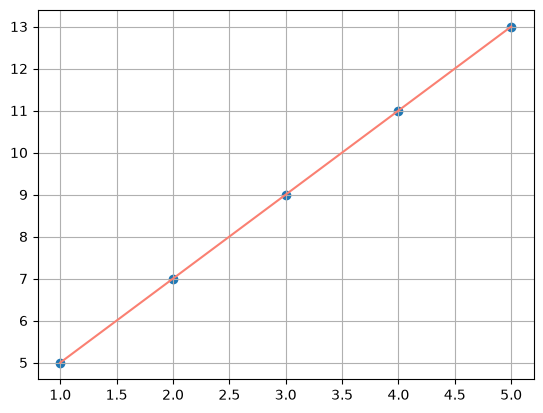

In [6]:
plt.plot(x, y, 'salmon')
plt.scatter(x, y)
plt.grid()
plt.show()


## 线性回归

In [8]:
x_input = [1,2,3,4,5]
y_input = [5,7,9,11,13]

#### 正向过程

##### 查看y预测值

In [11]:
# 正向过程，查看y预测值
graph = tf.Graph()
with graph.as_default():
    w = tf.Variable(0.5, dtype=tf.float32, name='w')
    b = tf.Variable(0.2, dtype=tf.float32, name='b')

    x = tf.placeholder(tf.float32, name='x')
    y = tf.placeholder(tf.float32, name='y')
    
    y_pred = w * x + b

with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    # tf中参数名称不能跟外界变量名称冲突
    y_pred_value = sess.run(y_pred, feed_dict={x: x_input})
    print(y_pred_value) 

[0.7 1.2 1.7 2.2 2.7]


##### 查看loss

In [13]:
# 正向过程，查看loss
graph = tf.Graph()
with graph.as_default():
    w = tf.Variable(0.5, dtype=tf.float32, name='w')
    b = tf.Variable(0.2, dtype=tf.float32, name='b')

    x = tf.placeholder(tf.float32, name='x')
    y = tf.placeholder(tf.float32, name='y')
    
    y_pred = w * x + b
    loss = tf.reduce_mean(tf.square(y_pred - y))

with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    y_pred_value,loss_value = sess.run([y_pred,loss], feed_dict={x: x_input, y: y_input})
    print(y_pred_value)
    print(loss_value)


[0.7 1.2 1.7 2.2 2.7]
57.79


##### 定义优化器

In [14]:
# 定义优化器，训练一次，查看w,b
graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(tf.float32, name='x')
    y = tf.placeholder(tf.float32, name='y')
    
    w = tf.Variable(0.5, dtype=tf.float32, name='w')
    b = tf.Variable(0.2, dtype=tf.float32, name='b')
    
    y_pred = w * x + b
    loss = tf.reduce_mean(tf.square(y_pred - y))

    optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.1)
    train_step = optimizer.minimize(loss)

with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    _,loss_value = sess.run([train_step,loss], feed_dict={x: x_input, y: y_input})
    print(loss_value)
    print(_)
    w_value,b_value = sess.run([w,b])
    print(w_value)
    print(b_value)


57.79
None
5.4800005
1.6600001


##### 循环训练

In [18]:
# 循环多次，查看最终结果
graph = tf.Graph()
with graph.as_default():
    x = tf.placeholder(tf.float32, name='x')
    y = tf.placeholder(tf.float32, name='y')
    
    w = tf.Variable(0.5, dtype=tf.float32, name='w')
    b = tf.Variable(0.2, dtype=tf.float32, name='b')
    
    y_pred = w * x + b
    loss = tf.reduce_mean(tf.square(y_pred - y))

    optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
    train_step = optimizer.minimize(loss)

with tf.Session(graph=graph) as sess:
    sess.run(tf.global_variables_initializer())
    for i in range(2000):
        _,loss_value = sess.run([train_step,loss], feed_dict={x: x_input, y: y_input})
        if i % 100 == 0:
            w_value,b_value = sess.run([w,b])
            print(f'w={w_value:.4f},b={b_value:.4f},loss={loss_value:.4f}')
    print('训练完成')
    w_value,b_value = sess.run([w,b])
    print(f'w={w_value:.4f},b={b_value:.4f}')


w=0.9980,b=0.3460,loss=57.7900
w=2.4357,b=1.4269,loss=0.4535
w=2.3105,b=1.8788,loss=0.2303
w=2.2213,b=2.2009,loss=0.1170
w=2.1577,b=2.4305,loss=0.0594
w=2.1124,b=2.5941,loss=0.0302
w=2.0801,b=2.7107,loss=0.0153
w=2.0571,b=2.7938,loss=0.0078
w=2.0407,b=2.8530,loss=0.0040
w=2.0290,b=2.8953,loss=0.0020
w=2.0207,b=2.9254,loss=0.0010
w=2.0147,b=2.9468,loss=0.0005
w=2.0105,b=2.9621,loss=0.0003
w=2.0075,b=2.9730,loss=0.0001
w=2.0053,b=2.9807,loss=0.0001
w=2.0038,b=2.9863,loss=0.0000
w=2.0027,b=2.9902,loss=0.0000
w=2.0019,b=2.9930,loss=0.0000
w=2.0014,b=2.9950,loss=0.0000
w=2.0010,b=2.9965,loss=0.0000
训练完成
w=2.0007,b=2.9975
